<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Tarea 2, Global Forecasting Multivariado**

**Límite de entrega para ser evaluado sobre 100 puntos:** 12 de Agosto, 23:59 (UTC-3)

Posteriormente pueden enviar la solución de la tarea, pero cada semana de atraso reduce 10 puntos la evaluación.

**Parte 1) Preparación de datos, 20 puntos**

* Fija las semillas de Python, NumPy y del
framework de deep learning que utilices.

* El archivo contiene una única serie temporal. Conviértela a formato panel generando entre 4 y 12 series, cada una identificada
por un series_id. Justifica el criterio de segmentación elegido. Ten en cuenta que en la Parte 2 deberás entrenar un modelo por serie: el número de series que elijas determina tu costo computacional.
* Horizonte de 24 horas.
* Variable objetivo: pollution (PM2.5).
* Longitud de la ventana de entrada y justifica la elección en términos de la dinámica de la serie.

* Define el tamaño del test y justifica el tamaño elegido.

* Construye los tensores de entrada y salida mediante ventanas deslizantes.

**Parte 2) Modelos, 40 puntos**

Todas las configuraciones de esta parte se evalúan sobre el mismo conjunto de test.

* Implementa un Baseline. Justifica tu elección y explica qué significaría que una red neuronal no lograra superarlo.

* Implementa un Modelo A. Una RNN simple compuesta por una capa recurrente (LSTM o GRU) seguida de la capa de salida. Documenta la arquitectura y el número de parámetros.

* Implementa un Modelo B. Una RNN profunda, arquitectura recurrente multicapa (utilizando LSTM y/o GRU). Documenta arquitectura y parámetros.

Entrena ahora las cuatro configuraciones siguientes:

| Configuración | Descripción |
|---|---|
| **Local, Modelo A** | Un modelo independiente por cada serie del panel |
| **Global, Modelo A** | Un único modelo entrenado sobre todas las series |
| **Local, Modelo B** | Un modelo independiente por cada serie del panel |
| **Global, Modelo B** | Un único modelo entrenado sobre todas las series |


**Parte 3) Embedding categórico, 20 puntos**

Incorpora series_id como variable categórica mediante una capa de *embedding*, enlas dos configuraciones globales.


Debes justificar:
* la dimensión del embedding elegida
* cómo se integra el vector estático con la secuencia de entrada

**Parte 4) Comparativa e interpretación, 10 puntos**

Tabla comparativa. Reúne las siete configuraciones: el baseline, las
cuatro de la Parte 2 y las dos de la Parte 3 en una única tabla que incluya:

- MAE
- número total de parámetros
- número de modelos entrenados (1 en las globales, N en las locales)
- mejora porcentual respecto al baseline

Acompaña la tabla con al menos un gráfico.

* Redacta la lectura de los resultados. ¿Qué diferencias son
sostenibles a partir de la evidencia disponible y cuáles no?

**Parte 5) Preguntas de análisis, 10 puntos**

* Un modelo global impone una única función a series con dinámicas distintas, lo que parece una desventaja frente a modelos locales especializados. ¿Por qué, aun así, suele obtener mejores resultados? ¿Bajo qué condiciones esperarías lo contrario?

* Supón que observas una mejora del 3% en MAE al añadir el embedding. ¿Qué evidencia adicional necesitas para sostener que esa mejora es real y no producto del azar en la inicialización? Indica qué calcularías concretamente.

**Entregable: notebook con el código corriendo y las respuestas a las 2 preguntas.**

**Link de entrega: [https://forms.gle/AJLpFTwypFJvjYETA](https://forms.gle/AJLpFTwypFJvjYETA)**

In [2]:
url_beijing = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"

### **Parte 1) Preparación de datos**

Serie horaria de PM2.5 de Beijing (UCI, 2010–2014). Se fijan las semillas, se convierte la serie única en un panel de 5 series anuales identificadas por `series_id`, se definen horizonte, ventana de entrada y tamaño del test, y se construyen los tensores mediante ventanas deslizantes.

- _Clase 4 "Global Forecasting Models" — celda de semillas (np.random.seed, keras.utils.set_random_seed)_
- _Clase 4 "Exploración de Series Multivariadas" — sección A) carga de pollution.csv, índice temporal con pd.to_datetime(year/month/day/hour), renombre pm2.5 → pm25, conteo de NaN_
- _Clase 4 "Global Forecasting Models" — loop por serie: estandarización con estadísticas de train, ventanas deslizantes, split temporal dentro de cada serie_

Silenciamos los mensajes informativos de TensorFlow

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

Importamos las librerías necesarias

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Desactivamos los avisos secundarios, esperables al crear varios modelos en un bucle

In [5]:
tf.get_logger().setLevel("ERROR")

Fijamos las semillas de Python, NumPy y TensorFlow para reproducibilidad

In [6]:
np.random.seed(42)
keras.utils.set_random_seed(42)

Descargamos el dataset horario de contaminación de Beijing y construimos el índice temporal

In [7]:
# Combinamos las columnas de fecha y hora en un único índice temporal
aire = pd.read_csv(url_beijing)
aire["fecha"] = pd.to_datetime(aire[["year", "month", "day", "hour"]])
aire = aire.set_index("fecha")

# Renombramos el target y nos quedamos solo con él (la variable objetivo es pollution / PM2.5)
aire = aire.rename(columns={"pm2.5": "pm25"})[["pm25"]]

print(f"{len(aire)} horas, de {aire.index.min()} a {aire.index.max()}")

43824 horas, de 2010-01-01 00:00:00 a 2014-12-31 23:00:00


In [8]:
display(aire.head())

,pm25
fecha,
2010-01-01 00:00:00,NaN
2010-01-01 01:00:00,NaN
2010-01-01 02:00:00,NaN
2010-01-01 03:00:00,NaN
2010-01-01 04:00:00,NaN


Contamos los valores faltantes del sensor de PM2.5

In [9]:
print(f"Valores faltantes de pm25: {aire['pm25'].isna().sum()}")
print(f"¿El primer día es todo NaN?: {aire['pm25'].iloc[:24].isna().all()}")

Valores faltantes de pm25: 2067
¿El primer día es todo NaN?: True


Tratamiento de faltantes: el primer día completo no tiene mediciones y se descarta. El resto se rellena con forward fill (`ffill`), que propaga el último valor observado: solo usa información del pasado. Interpolar usaría valores futuros para rellenar el presente (leakage temporal).

In [10]:
# Descartamos el primer día (sin mediciones) y rellenamos el resto con el último valor observado
aire = aire.iloc[24:].copy()
aire["pm25"] = aire["pm25"].ffill()
print(f"Faltantes tras el tratamiento: {aire['pm25'].isna().sum()}")

Faltantes tras el tratamiento: 0


**Criterio de segmentación del panel: un `series_id` por año calendario (5 series).**

* Cada corte es un bloque contiguo, condición necesaria para que las ventanas deslizantes de cada serie sean válidas (no hay saltos temporales dentro de una serie).
* 5 series está dentro del rango pedido (4–12) y acota el costo computacional de la Parte 2: 5 modelos locales por arquitectura.
* Cada serie contiene el ciclo estacional anual completo (inviernos con picos de polución, veranos más limpios), de modo que las 5 series comparten la misma estructura estacional y el panel tiene sentido para un modelo global.

In [11]:
# Un series_id por año calendario
panel = {str(anio): g["pm25"].values.astype("float32") for anio, g in aire.groupby(aire.index.year)}
series_ids = sorted(panel.keys())

for sid in series_ids:
    print(f"  serie {sid}: {len(panel[sid])} horas")

  serie 2010: 8736 horas
  serie 2011: 8760 horas
  serie 2012: 8784 horas
  serie 2013: 8760 horas
  serie 2014: 8760 horas


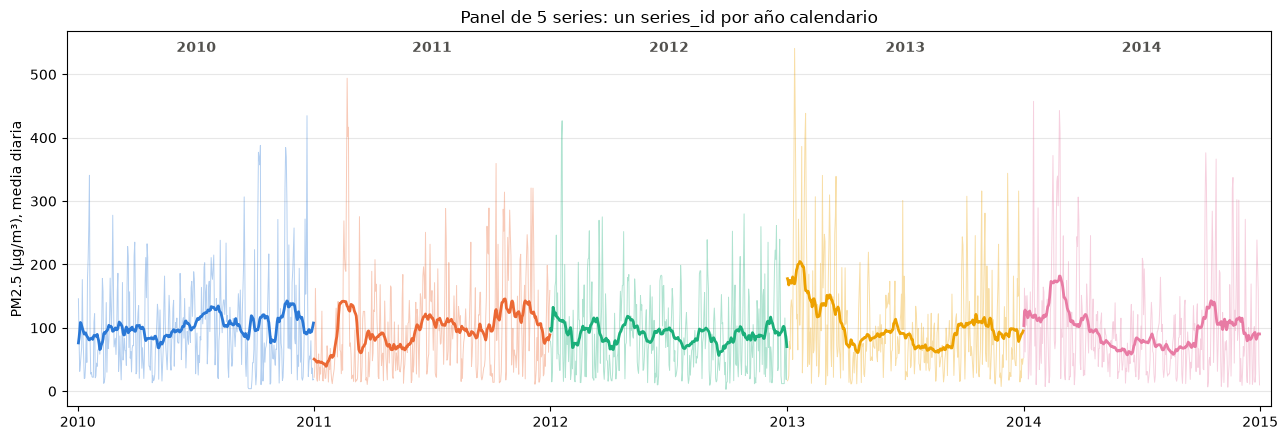

In [ ]:
colores = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
diarias = {sid: aire["pm25"][aire.index.year == int(sid)].resample("D").mean() for sid in series_ids}

fig, ax = plt.subplots(figsize=(13, 4.5))
for sid, color in zip(series_ids, colores):
    # Media diaria de fondo: muestra la volatilidad real que enfrenta el modelo
    ax.plot(diarias[sid].index, diarias[sid].values, color=color, linewidth=0.7, alpha=0.35)
    # Media móvil de 30 días: deja ver el ciclo estacional de cada serie
    suave = diarias[sid].rolling(30, center=True, min_periods=1).mean()
    ax.plot(suave.index, suave.values, color=color, linewidth=2.0)

altura = max(d.max() for d in diarias.values())
for sid in series_ids:
    medio = diarias[sid].index[len(diarias[sid]) // 2]
    ax.text(medio, altura * 0.99, sid, ha="center", color="#52514e", fontsize=10, fontweight="bold")

ax.set_ylabel("PM2.5 (µg/m³), media diaria")
ax.set_title("Panel de 5 series: un series_id por año calendario")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

**Horizonte y ventana de entrada.** El horizonte lo fija la consigna: H = 24 horas. Para la ventana de entrada se elige L = 48 horas (dos días): el PM2.5 tiene un ciclo diario marcado, y con 48 horas cada ventana contiene dos ciclos diarios completos, incluida la transición entre días, sin encarecer de más el entrenamiento.

In [12]:
L = 48  # ventana de entrada: dos ciclos diarios completos
H = 24  # horizonte de 24 horas, fijado por la consigna

**Tamaño del test: N_TEST = 720 ventanas (30 días) por serie.** Un mes de condiciones variadas permite estimar el MAE con estabilidad y deja mas deñ 90% de cada serie para entrenar. Al segmentar por año, el test de las 5 series cae en diciembre: invierno, la época de picos de polución un test exigente y, sobre todo, idéntico en calendario para todas las series, lo que hace comparables sus errores.

In [13]:
N_TEST = 720  # últimas 720 ventanas (30 días) de cada serie

Recorremos serie por serie construyendo su dataset supervisado con ventanas deslizantes

In [ ]:
X_tr, y_tr, X_te, y_te, escalas = {}, {}, {}, {}, {}

# Horas cubiertas por los targets de las ventanas de test queda fuera de las estadísticas de estandarización
corte_test = N_TEST + H - 1

for sid in series_ids:
    v = panel[sid]                  # Extraemos la serie del año como array de numpy
    # Calculamos media y desvío usando solo el tramo de entrenamiento de esta serie
    mu = v[:-corte_test].mean()
    sd = v[:-corte_test].std()
    # Guardamos las estadísticas para desestandarizar el error después
    escalas[sid] = (mu, sd)
    # Estandarizamos la serie
    z = (v - mu) / sd
    # Construimos las ventanas deslizantes: 48 horas de input, 24 horas de target
    Xs, ys = [], []
    for t in range(L, len(z) - H + 1):
        Xs.append(z[t - L:t].reshape(-1, 1))
        ys.append(z[t:t + H])

    Xs = np.array(Xs, dtype="float32")
    ys = np.array(ys, dtype="float32")

    # Realizamos el split temporal dentro de esta serie
    X_tr[sid], X_te[sid] = Xs[:-N_TEST], Xs[-N_TEST:]
    y_tr[sid], y_te[sid] = ys[:-N_TEST], ys[-N_TEST:]

    print(f"  serie {sid}: {len(X_tr[sid])} ventanas de train, {len(X_te[sid])} de test")
print(f"\nForma del input: {X_tr[series_ids[0]].shape[1:]} -> target: {y_tr[series_ids[0]].shape[1:]}")

  serie 2010: 7945 ventanas de train, 720 de test
  serie 2011: 7969 ventanas de train, 720 de test
  serie 2012: 7993 ventanas de train, 720 de test
  serie 2013: 7969 ventanas de train, 720 de test
  serie 2014: 7969 ventanas de train, 720 de test

Forma del input: (48, 1) -> target: (24,)


### **Parte 2) Modelos**

Un baseline sin parámetros y dos arquitecturas recurrentes (A: una capa; B: multicapa), entrenadas en configuración local (un modelo por serie) y global (un único modelo sobre el pool). Las cuatro configuraciones comparten hiperparámetros de entrenamiento y se evalúan sobre el mismo test.

- _Clase 4 "Global Forecasting Models" — sección A) Baseline: Seasonal Naive (la predicción se extrae de la propia ventana de entrada)_
- _Clase 4 "Global Forecasting Models" — sección B) Local: un modelo por industria (loop de construcción, fit por serie, MAE desestandarizado, clear_session)_
- _Clase 4 "Global Forecasting Models" — sección C) Global: pooling con np.concatenate, un solo fit, evaluación por serie_
- _Clase 3 "LSTM, GRU y Benchmark contra el Naive" — misma semilla antes de cada entrenamiento para comparar justo; conteo de parámetros de la celda recurrente_
- _Clase 3 "Rollout Recursivo" — el modelo bueno a un paso colapsa al realimentar sus errores: justifica la salida directa Dense(24) para las 24 horas del horizonte_

**Baseline: seasonal naive diario.** Predice que las próximas 24 horas serán iguales a las últimas 24 horas observadas (el mismo patrón horario de "ayer"). Se elige porque explota la estacionalidad dominante de la serie, el ciclo diario, sin ningún parámetro, igual que el seasonal naive. No se ve una componente de tendencia para todo el periodo. 
 
Si una red neuronal no lo supera, significa que con todo su costo de entrenamiento no aprendió nada más que la persistencia del ciclo diario, y su uso no se justifica frente a una regla gratuita.

In [ ]:
mae_baseline = {}
for sid in series_ids:
    pred = X_te[sid][:, -H:, 0]             # Tomamos las últimas 24 horas de cada ventana como predicción de las próximas 24
    # Calculamos el MAE y lo llevamos a la escala original (µg/m³)
    mae_baseline[sid] = np.abs(pred - y_te[sid]).mean() * escalas[sid][1]
    print(f"  serie {sid}: MAE naive = {mae_baseline[sid]:.1f}")

  serie 2010: MAE naive = 93.6
  serie 2011: MAE naive = 82.2
  serie 2012: MAE naive = 74.6
  serie 2013: MAE naive = 82.3
  serie 2014: MAE naive = 77.8


**Modelos A y B.** Se definen como funciones constructoras para garantizar que las configuraciones local y global usen exactamente la misma arquitectura. La cabeza `Dense(24)` produce el horizonte completo de una sola pasada (estrategia directa, sin realimentar predicciones).

* Modelo A: `LSTM(16) → Dense(24)`, una capa recurrente seguida de la capa de salida.
* Modelo B: `LSTM(32, return_sequences=True) → LSTM(16) → Dense(24)`, arquitectura recurrente profunda: la primera capa devuelve la secuencia completa y la segunda la resume.

In [ ]:
UNIDADES = 16

def construir_modelo_a():
    entrada = keras.Input(shape=(L, 1))         # Entrada: 48 pasos temporales con 1 variable
    h = layers.LSTM(UNIDADES)(entrada)          # Una única capa recurrente
    salida = layers.Dense(H)(h)                  # Cabeza de salida: las 24 horas del horizonte en una sola pasada
    return keras.Model(entrada, salida, name="modelo_a")


def construir_modelo_b():
    entrada = keras.Input(shape=(L, 1))      # Entrada: 48 pasos temporales con 1 variable
    h = layers.LSTM(2 * UNIDADES, return_sequences=True)(entrada)   # Primera capa recurrente: devuelve la secuencia completa para alimentar a la siguiente
    h = layers.LSTM(UNIDADES)(h)            # Segunda capa recurrente: resume la secuencia en un único estado
    salida = layers.Dense(H)(h)             # Cabeza de salida
    return keras.Model(entrada, salida, name="modelo_b")

Documentamos la arquitectura y el número de parámetros del Modelo A

In [17]:
modelo_a = construir_modelo_a()
modelo_a.summary()

Model: "modelo_a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560 (6.09 KB)

 Trainable params: 1,560 (6.09 KB)

 Non-trainable params: 0 (0.00 B)

Documentamos la arquitectura y el número de parámetros del Modelo B

In [18]:
modelo_b = construir_modelo_b()
modelo_b.summary()
keras.backend.clear_session()

Model: "modelo_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,896 (30.84 KB)

 Trainable params: 7,896 (30.84 KB)

 Non-trainable params: 0 (0.00 B)

**Configuración de entrenamiento**, idéntica en las cuatro configuraciones: Adam(1e-3), pérdida MSE, 15 épocas, batch 64 en los locales y 256 en el global. 

In [19]:
EPOCAS = 15
LR = 1e-3
BATCH_LOCAL = 64
BATCH_GLOBAL = 256

Definimos el ciclo de entrenamiento local: construir, compilar, entrenar y evaluar un modelo independiente por serie

In [ ]:
def entrenar_local(constructor):
    mae, params = {}, 0

    for sid in series_ids:
        modelo = constructor()
        modelo.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
        params += modelo.count_params()     # Acumulamos los parámetros de este modelo al total del enfoque local

        # Entrenamos solo con las ventanas de esta serie
        modelo.fit(X_tr[sid], y_tr[sid], epochs=EPOCAS, batch_size=BATCH_LOCAL, verbose=0)
        # Predecimos sobre el test de esta serie y desestandarizamos el error
        pred = modelo.predict(X_te[sid], verbose=0)
        mae[sid] = np.abs(pred - y_te[sid]).mean() * escalas[sid][1]
        print(f"  serie {sid}: MAE = {mae[sid]:.1f}")

        keras.backend.clear_session()  # Liberamos la memoria
    return mae, params

Apilamos las ventanas de entrenamiento de todas las series en un solo pool: la única diferencia conceptual con el enfoque local

In [21]:
X_pool = np.concatenate([X_tr[sid] for sid in series_ids], axis=0)
y_pool = np.concatenate([y_tr[sid] for sid in series_ids], axis=0)
print(f"Pool global: {X_pool.shape[0]} ventanas de {len(series_ids)} series")

Pool global: 39845 ventanas de 5 series


Definimos el ciclo de entrenamiento global: un único modelo entrenado sobre el pool, evaluado sobre el test de cada serie por separado

In [ ]:
def entrenar_global(constructor):
    # Construimos y compilamos el único modelo del enfoque global
    modelo = constructor()
    modelo.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    params = modelo.count_params()

    # Entrenamos sobre el pool completo
    modelo.fit(X_pool, y_pool, epochs=EPOCAS, batch_size=BATCH_GLOBAL, verbose=0)
    # Evaluamos sobre el test de cada serie por separado: el promedio esconde exactamente lo que queremos ver, la variación por serie
    mae = {}
    for sid in series_ids:
        pred = modelo.predict(X_te[sid], verbose=0)
        mae[sid] = np.abs(pred - y_te[sid]).mean() * escalas[sid][1]
        print(f"  serie {sid}: MAE = {mae[sid]:.1f}")

    keras.backend.clear_session()
    return mae, params

**Local, Modelo A:** un modelo independiente por cada serie del panel

In [23]:
print("Local, Modelo A: 5 modelos, uno por serie")
mae_local_a, params_local_a = entrenar_local(construir_modelo_a)

Local, Modelo A: 5 modelos, uno por serie
  serie 2010: MAE = 62.4
  serie 2011: MAE = 58.4
  serie 2012: MAE = 53.6
  serie 2013: MAE = 63.2
  serie 2014: MAE = 62.3


**Global, Modelo A:** un único modelo entrenado sobre todas las series

In [24]:
print("Global, Modelo A: 1 modelo sobre el pool")
mae_global_a, params_global_a = entrenar_global(construir_modelo_a)

Global, Modelo A: 1 modelo sobre el pool
  serie 2010: MAE = 60.1
  serie 2011: MAE = 58.1
  serie 2012: MAE = 53.7
  serie 2013: MAE = 60.3
  serie 2014: MAE = 58.0


**Local, Modelo B:** un modelo independiente por cada serie del panel

In [25]:
print("Local, Modelo B: 5 modelos, uno por serie")
mae_local_b, params_local_b = entrenar_local(construir_modelo_b)

Local, Modelo B: 5 modelos, uno por serie
  serie 2010: MAE = 60.7
  serie 2011: MAE = 60.5
  serie 2012: MAE = 57.4
  serie 2013: MAE = 63.1
  serie 2014: MAE = 63.9


**Global, Modelo B:** un único modelo entrenado sobre todas las series

In [26]:
print("Global, Modelo B: 1 modelo sobre el pool")
mae_global_b, params_global_b = entrenar_global(construir_modelo_b)

Global, Modelo B: 1 modelo sobre el pool
  serie 2010: MAE = 60.8
  serie 2011: MAE = 56.8
  serie 2012: MAE = 54.9
  serie 2013: MAE = 61.5
  serie 2014: MAE = 57.0


### **Parte 3) Embedding categórico**

Se incorpora `series_id` como variable categórica mediante una capa de embedding en las dos configuraciones globales.

- _Clase 4 "Embeddings Categóricos" — mapeo de cada serie a un entero (fila de la lookup table), arrays de identificadores por ventana en pool y test_
- _Clase 4 "Embeddings Categóricos" — sección B) Global + Embedding: capa Embedding, repetición del vector estático con tf.repeat, Concatenate(axis=2), modelo de dos entradas, fit y evaluación pasando el identificador_

Mapeamos cada serie a un entero: la fila de la tabla de embeddings. El entero no tiene significado ordinal

In [ ]:
id_serie = {sid: i for i, sid in enumerate(series_ids)}
N_SERIES = len(series_ids)

# Identificador repetido una vez por ventana de train, alineado con el orden del pool
id_pool = np.concatenate([
    np.full((len(X_tr[sid]),), id_serie[sid], dtype="int32") for sid in series_ids
])
# Identificadores del test de cada serie
id_te = {sid: np.full((len(X_te[sid]),), id_serie[sid], dtype="int32") for sid in series_ids}

print("Codificación de series:")
for sid, i in id_serie.items():
    print(f"  {i}: {sid}")

Codificación de series:
  0: 2010
  1: 2011
  2: 2012
  3: 2013
  4: 2014


**Dimensión del embedding: DIM_EMB = 3.** Regla práctica: aproximadamente la mitad del número de categorías, `(N_series + 1) // 2 = 3`. Con solo 5 categorías, una dimensión mayor agrega capacidad de memorización por serie que los datos no necesariamente pueden pagar.

In [28]:
DIM_EMB = 3

**Integración del vector estático con la secuencia.** El embedding devuelve un vector por serie que es estático: no cambia con el tiempo. La secuencia sí. Para combinarlos, el vector se repite en los L = 48 pasos temporales de la ventana (`tf.repeat`) y se concatena por canal (`Concatenate(axis=2)`): el input de la capa recurrente pasa de 1 a 1 + 3 = 4 canales por paso temporal. Así la red ve en todo momento qué serie está leyendo, y el embedding se entrena por backpropagation junto al resto de la red.

In [ ]:
def construir_modelo_a_emb():
    # Dos entradas: la ventana numérica y el identificador categórico
    entrada_serie = keras.Input(shape=(L, 1), name="ventana")
    entrada_id = keras.Input(shape=(1,), dtype="int32", name="id_serie")
    # Lookup table diferenciable: N_SERIES filas x DIM_EMB columnas
    emb = layers.Embedding(N_SERIES, DIM_EMB, name="embedding_serie")(entrada_id)

    # Repetimos el vector estático en los L pasos temporales de la ventana
    emb_repetido = layers.Lambda(
        lambda x: tf.repeat(x, repeats=L, axis=1),
        output_shape=(L, DIM_EMB),
    )(emb)
    # Concatenamos por canal: el input pasa de 1 a 1 + DIM_EMB canales
    entrada_combinada = layers.Concatenate(axis=2)([entrada_serie, emb_repetido])
    h = layers.LSTM(UNIDADES)(entrada_combinada)
    salida = layers.Dense(H)(h)

    return keras.Model([entrada_serie, entrada_id], salida, name="modelo_a_emb")


def construir_modelo_b_emb():
    entrada_serie = keras.Input(shape=(L, 1), name="ventana")
    entrada_id = keras.Input(shape=(1,), dtype="int32", name="id_serie")
    emb = layers.Embedding(N_SERIES, DIM_EMB, name="embedding_serie")(entrada_id)

    emb_repetido = layers.Lambda(
        lambda x: tf.repeat(x, repeats=L, axis=1),
        output_shape=(L, DIM_EMB),
    )(emb)
    entrada_combinada = layers.Concatenate(axis=2)([entrada_serie, emb_repetido])

    # Mismo cuerpo recurrente que el Modelo B
    h = layers.LSTM(2 * UNIDADES, return_sequences=True)(entrada_combinada)
    h = layers.LSTM(UNIDADES)(h)
    salida = layers.Dense(H)(h)

    return keras.Model([entrada_serie, entrada_id], salida, name="modelo_b_emb")

Definimos el ciclo de entrenamiento global con identificador: las dos entradas se pasan en simultáneo

In [ ]:
def entrenar_global_emb(constructor):
    # Construimos y compilamos el modelo de dos entradas
    modelo = constructor()
    modelo.compile(optimizer=keras.optimizers.Adam(LR), loss="mse")
    params = modelo.count_params()
    # Entrenamos con la ventana y el identificador en simultáneo
    modelo.fit(
        [X_pool, id_pool.reshape(-1, 1)], y_pool,
        epochs=EPOCAS, batch_size=BATCH_GLOBAL, verbose=0,
    )
    # Evaluamos por serie pasando también el identificador
    mae = {}
    for sid in series_ids:
        pred = modelo.predict([X_te[sid], id_te[sid].reshape(-1, 1)], verbose=0)
        mae[sid] = np.abs(pred - y_te[sid]).mean() * escalas[sid][1]
        print(f"  serie {sid}: MAE = {mae[sid]:.1f}")

    keras.backend.clear_session()
    return mae, params

**Global, Modelo A + embedding**

In [31]:
print("Global, Modelo A + embedding")
mae_emb_a, params_emb_a = entrenar_global_emb(construir_modelo_a_emb)

Global, Modelo A + embedding
  serie 2010: MAE = 59.4
  serie 2011: MAE = 58.3
  serie 2012: MAE = 54.0
  serie 2013: MAE = 60.9
  serie 2014: MAE = 59.8


**Global, Modelo B + embedding**

In [32]:
print("Global, Modelo B + embedding")
mae_emb_b, params_emb_b = entrenar_global_emb(construir_modelo_b_emb)

Global, Modelo B + embedding
  serie 2010: MAE = 60.6
  serie 2011: MAE = 58.6
  serie 2012: MAE = 54.9
  serie 2013: MAE = 59.2
  serie 2014: MAE = 62.2


### **Parte 4) Comparativa e interpretación**

- _Clase 4 "Global Forecasting Models" — sección D) Comparativa: tabla por serie con columna del ganador, conteo de parámetros totales por enfoque_
- _Clase 4 "Embeddings Categóricos" — mejora porcentual respecto al promedio, comparación por serie_
- _Clase 2 "Baselines Modernos" — tabla comparativa de métricas con pd.DataFrame_

Reunimos las siete configuraciones en una única tabla. El MAE reportado es el promedio de los MAE por serie, en µg/m³

In [33]:
configuraciones = [
    ("Baseline (seasonal naive)", mae_baseline, 0, 0),
    ("Local, Modelo A", mae_local_a, params_local_a, N_SERIES),
    ("Global, Modelo A", mae_global_a, params_global_a, 1),
    ("Local, Modelo B", mae_local_b, params_local_b, N_SERIES),
    ("Global, Modelo B", mae_global_b, params_global_b, 1),
    ("Global, Modelo A + embedding", mae_emb_a, params_emb_a, 1),
    ("Global, Modelo B + embedding", mae_emb_b, params_emb_b, 1),
]

# MAE promedio del baseline, la referencia de la mejora porcentual
mae_base = np.mean(list(mae_baseline.values()))

filas = []
for nombre, maes, params, n_modelos in configuraciones:
    mae_prom = np.mean(list(maes.values()))
    filas.append({
        "Configuración": nombre,
        "MAE (µg/m³)": round(mae_prom, 1),
        "Parámetros": params,
        "Modelos entrenados": n_modelos,
        "Mejora vs baseline (%)": round((1 - mae_prom / mae_base) * 100, 1),
    })

tabla = pd.DataFrame(filas).set_index("Configuración")
tabla

,MAE (µg/m³),Parámetros,Modelos entrenados,Mejora vs baseline (%)
Configuración,,,,
Baseline (seasonal naive),82.099998,0,0,0.0
"Local, Modelo A",60.000000,7800,5,26.9
"Global, Modelo A",58.000000,1560,1,29.3
"Local, Modelo B",61.099998,39480,5,25.5
"Global, Modelo B",58.200001,7896,1,29.1
"Global, Modelo A + embedding",58.500000,1767,1,28.8
"Global, Modelo B + embedding",59.099998,8295,1,28.0


Comparamos el MAE por serie y configuración, con la configuración ganadora de cada serie

In [34]:
columnas = [
    ("Naive", mae_baseline), ("Loc A", mae_local_a), ("Glob A", mae_global_a),
    ("Loc B", mae_local_b), ("Glob B", mae_global_b),
    ("Glob A+emb", mae_emb_a), ("Glob B+emb", mae_emb_b),
]

encabezado = f"{'Serie':<8}" + "".join(f"{n:>12}" for n, _ in columnas) + f"{'Gana':>14}"
print(encabezado)
print("-" * len(encabezado))
for sid in series_ids:
    valores = [m[sid] for _, m in columnas]
    ganador = columnas[int(np.argmin(valores))][0]
    print(f"{sid:<8}" + "".join(f"{v:>12.1f}" for v in valores) + f"{ganador:>14}")

Serie          Naive       Loc A      Glob A       Loc B      Glob B  Glob A+emb  Glob B+emb          Gana
----------------------------------------------------------------------------------------------------------
2010            93.6        62.4        60.1        60.7        60.8        59.4        60.6    Glob A+emb
2011            82.2        58.4        58.1        60.5        56.8        58.3        58.6        Glob B
2012            74.6        53.6        53.7        57.4        54.9        54.0        54.9         Loc A
2013            82.3        63.2        60.3        63.1        61.5        60.9        59.2    Glob B+emb
2014            77.8        62.3        58.0        63.9        57.0        59.8        62.2        Glob B


Graficamos el MAE promedio de cada configuración, de mejor a peor

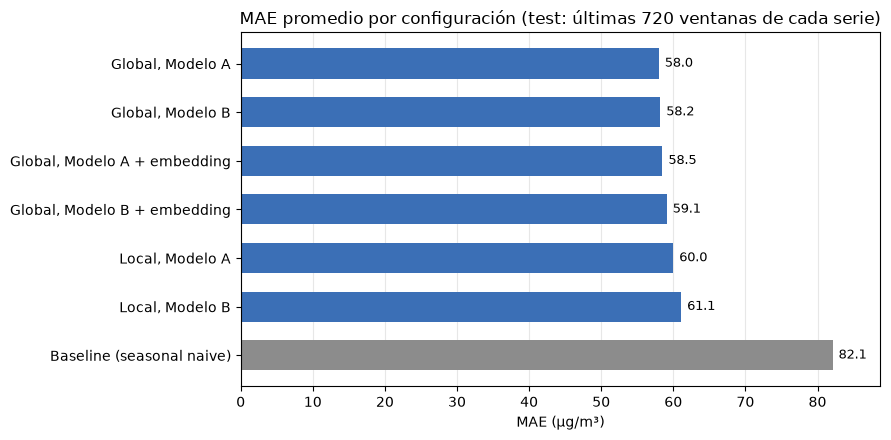

In [35]:
# Ordenamos de mejor a peor MAE
orden = tabla["MAE (µg/m³)"].sort_values(ascending=True)

# Un solo tono para los modelos; el baseline (la referencia) en gris
colores = ["#8C8C8C" if "Baseline" in nombre else "#3B6FB6" for nombre in orden.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(orden.index[::-1], orden.values[::-1], color=colores[::-1], height=0.62)

# Etiquetamos el valor al final de cada barra
for i, valor in enumerate(orden.values[::-1]):
    ax.text(valor + orden.max() * 0.01, i, f"{valor:.1f}", va="center", fontsize=9)

ax.set_xlabel("MAE (µg/m³)")
ax.set_title("MAE promedio por configuración (test: últimas 720 ventanas de cada serie)")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.margins(x=0.08)
plt.tight_layout()
plt.show()

**Lectura de los resultados.**

* **Sostenible: todas las redes le ganan al baseline.** El seasonal naive diario queda en 82,1 µg/m³ y todas las configuraciones neuronales bajan a 58–61 µg/m³ (mejoras del 25,5% al 29,3%), y lo hacen en las 5 series sin excepción, con márgenes amplios en cada una. Con esa magnitud y consistencia, la diferencia no es atribuible al azar de una corrida.
* **Sostenible con matices: global ≥ local.** El global mejora al local en 4 de las 5 series con cada arquitectura, y en la serie restante pierde por apenas 0,1 µg/m³ con una fracción de los parámetros a mantener (Global A: 1.560 contra 7.800 del Local A; Global B: 7.896 contra 39.480 del Local B) y un solo modelo en lugar de cinco. La dirección del efecto es consistente; su tamaño por serie (0,3 a 4,3 µg/m³) es moderado.
* **No sostenible: A vs B y el efecto del embedding.** El Modelo B (profundo) no mejora al A en ninguna configuración (58,2 vs 58,0 en global; 61,1 vs 60,0 en local): la capacidad extra no encuentra señal adicional que la pague. El embedding directamente empeora el promedio (58,0 → 58,5 con A; 58,2 → 59,1 con B) y su efecto cambia de signo según la serie (gana solo en 2010 con A, y en 2010 y 2013 con B). Diferencias de menos de 1 µg/m³ medidas con una única semilla están dentro del ruido de inicialización y no permiten concluir nada (ver Parte 5, pregunta 2).
* La tabla por serie muestra además que el "ganador" absoluto cambia de serie en serie (A+embedding en 2010, B global en 2011 y 2014, A local en 2012, B+embedding en 2013): otra señal de que las diferencias finas entre configuraciones neuronales no son estables.

### **Parte 5) Preguntas de análisis**

**1) Un modelo global impone una única función a series con dinámicas distintas, lo que parece una desventaja frente a modelos locales especializados. ¿Por qué, aun así, suele obtener mejores resultados? ¿Bajo qué condiciones esperarías lo contrario?**

Por tres razones que esta tarea ilustra:

* **Más datos para los mismos parámetros.** El pooling entrena la misma red con ~39.800 ventanas en lugar de ~8.000: cinco veces más evidencia para estimar cada peso. En esta corrida el Global A, con 1.560 parámetros, rinde mejor (58,0 µg/m³) que los cinco Locales A que suman 7.800 (60,0).
* **Las series comparten dinámica.** Los 5 años son el mismo proceso físico, el mismo sensor, el mismo ciclo diario y el mismo ciclo estacional de la polución, así que la "única función" impuesta no es una limitación real: es la función correcta para todas. Es el equivalente de la correlación media de 0,76 entre industrias que en clase justificaba el pooling del panel de desempleo.
* **Regularización implícita.** Al tener que servir a todas las series a la vez, el modelo global no puede memorizar idiosincrasias de una serie particular (el ruido de un año concreto); solo puede aprender lo que se repite en todas por lo que lo hace generalizar mejor.

**Esperaría lo contrario** cuando falla alguna de esas condiciones: series con dinámicas genuinamente heterogéneas (procesos distintos, estacionalidades distintas), donde la función única promedia regímenes incompatibles; series con datos abundantes, donde el local deja de estar hambriento de datos, donde varios locales ni siquiera superaban al naive; o paneles de pocas series poco relacionadas, donde el pooling aporta poca evidencia extra y sí interferencia.

**2) Supón que observas una mejora del 3% en MAE al añadir el embedding. ¿Qué evidencia adicional necesitas para sostener que esa mejora es real y no producto del azar en la inicialización? Indica qué calcularías concretamente.**

En esta corrida el punto es tangible: con una única semilla, el embedding no mejoró sino que empeoró el promedio (58,0 → 58,5 con A; 58,2 → 59,1 con B). Un ±3% observado una sola vez es indistinguible del ruido de inicialización. Se deberia probar:

1. **Repetición con K semillas.** Reentrenar el par (global con y sin embedding) con K semillas distintas, cambiando solo la inicialización, y calcular la media y el desvío estándar de la diferencia por par. La mejora es sostenible solo si la media de las diferencias supera con claridad su variabilidad.
2. **Desagregación por serie.** La diferencia por serie y semilla: si la mejora promedio proviene de 1 o 2 series y en el resto empeora (aquí el embedding gana solo en 2010 con A, y en 2010 y 2013 con B), no hay un efecto general del embedding sino variación específica de algunas series.

El marco conceptual es el de clase: el embedding le devuelve al modelo la capacidad de memorizar por serie que el pooling le había quitado. Esa capacidad extra es una hipótesis que los datos deben poder pagar y con 5 series, una semilla y diferencias menores a 1 µg/m³, aquí no la pagan.